In [1]:
# =========================
# AOEnv 测试 notebook 脚本
# =========================

import sys
import os
sys.path.append('/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO')
sys.path.append(os.path.dirname(os.getcwd()))
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt

# 导入 AOEnv
from AdaptiveOpticsEnvR2DISC_v3 import AOEnv  # 替换为你的AOEnv.py实际路径或包名

# 构造 args
args = SimpleNamespace(
    agent = "PPO",
    episodes = 10,
    seed = 0,
    maxStep = 200,
    gainCL = 0.1,
    samplingRate = 100,
    exposureTime = 0.1,
    clockRate = 100,
    lightRatio = 0.6,
    paramFile = "paramFile4",  
    k = 3,
    delay=0
)

# 创建环境
env = AOEnv(args)






     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
1.26.2
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           128             [pixels]     
    Pixel Size           0.03              [m]        
     Surface             12.0              [m2]   

 11%|█         | 1/9 [00:03<00:24,  3.07s/it]

100/856
Time elapsed: 3.073512315750122 s


 22%|██▏       | 2/9 [00:06<00:21,  3.06s/it]

200/856
Time elapsed: 3.0429329872131348 s


...

 89%|████████▉ | 8/9 [00:22<00:02,  2.77s/it]

800/856
Time elapsed: 2.6738948822021484 s


100%|██████████| 9/9 [00:24<00:00,  2.70s/it]

900/856
Time elapsed: 1.5316174030303955 s


No Modal Gains found. All gains set to 1


In [2]:
print(env.tel.OPD.shape)

(128, 128, 56)


In [3]:
for key in env.param.keys():
    print(key,':',env.param[key])

r0 : 0.15
L0 : 30
fractionnalR0 : [0.7, 0.25, 0.05]
windSpeed : [5, 10, 20]
windDirection : [0, 90, 360]
altitude : [0, 4000, 10000]
resolution : 128
diameter : 4
sampling_rate : 1000
centralObstruction : 0.2
magnitude : 5
opticalBand : I
nSubap : 32
mechCoupling : 0.1
lightRatio : 0.6
is_geometric : False
threshold_cog : 0.01
field_stop_size : 64
nyquist_sampling : 4
photonNoise : True
readoutNoise : 1
darkCurrent : 0.0001
nModes : 200
name : VLT_I_band_32x32
pathInput : data_calibration/
pathOutput : data_cl/
agent : PPO
episodes : 10
seed : 0
maxStep : 200
gainCL : 0.1
samplingRate : 100
exposureTime : 0.1
clockRate : 100
k : 3
delay : 0


In [4]:
env.reset()
action = [6,19,18,19]
list(env.get_action_from_discrete(action))
done = False
episode_return=0
# plt.imshow(env.camH.referenceFrame)
while not done:
        state, reward, done, info = env.step(action)
        episode_return += reward
        print("step:",env.current_step," --- ","reward:",reward,"SR:",env.camH.strehl)

-> Computing the initial phase screen...
initial phase screen : 0.034033775329589844 s
ZZt.. : 2.6139442920684814 s
ZXt.. : 0.2616240978240967 s
XXt.. : 0.13525867462158203 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.009712696075439453 s
ZZt.. : 1.6689300537109375e-06 s
ZXt.. : 2.8133392333984375e-05 s
XXt.. : 8.344650268554688e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.009349584579467773 s
ZZt.. : 2.384185791015625e-06 s
ZXt.. : 3.3855438232421875e-05 s
XXt.. : 8.821487426757812e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
WARNING !!!! THE LIGHT IN THE SUBAPERTURE IS MAYBE WRAPPING !!!7.2 % of the total flux detected on the edges of the subapertures. You may want to increase the seeing value o

KeyboardInterrupt: 

In [5]:
print(list(env.get_action_from_discrete(action)),np.mean(env.inst_SR),np.mean(env.actual_SR))

[0.4, 100.0, 0.5, 100.0] 0.41543972630493137 0.3824962585094462


In [7]:
env.inst_SR.clear()
env.inst_SR

[]

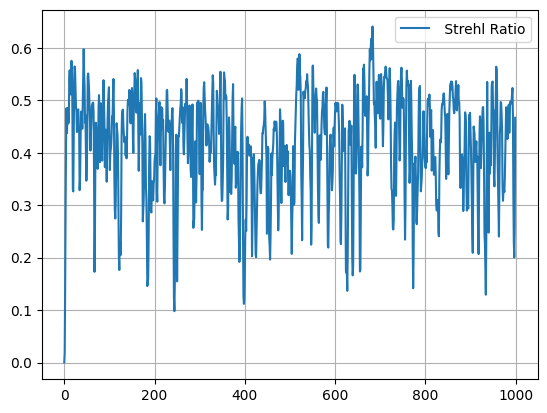

In [6]:
plt.figure()
# plt.plot(np.arange(param['nLoop']), SR_camH1, label='old imager Strehl Ratio')
plt.plot(np.arange(len(env.inst_SR)), env.inst_SR, label=' Strehl Ratio')

plt.legend()
plt.grid()
plt.show() 

In [8]:
np.exp(-np.var(env.tel.src.phase[np.where(env.tel.pupil==1)]))

0.46650085361742943

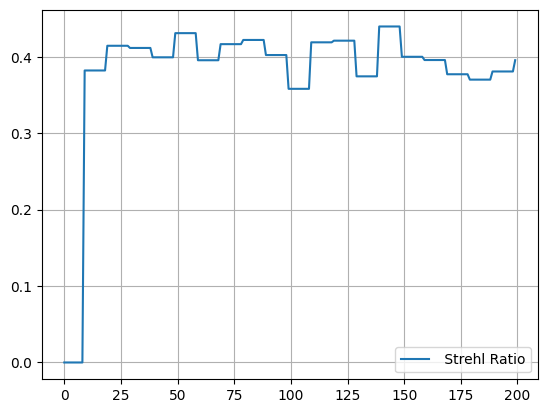

In [7]:
plt.figure()
# plt.plot(np.arange(param['nLoop']), SR_camH1, label='old imager Strehl Ratio')
plt.plot(np.arange(len(env.actual_SR)), env.actual_SR, label=' Strehl Ratio')

plt.legend()
plt.grid()
plt.show() 

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 记录所有 gain 下的平均 SR
average_SR_list = []
return_list = []
# 扫描所有 gain index
for gain_index in range(env.gain_dim):
    obs = env.reset()
    episode_return = 0
    done = False

    # 构造动作
    action = [gain_index, 9,8,9]  

    while not done:
        state, reward, done, info = env.step(action)
        episode_return += reward

    # 计算当前 gain 下平均 SR
    avg_SR = np.mean(env.SR)
    average_SR_list.append(avg_SR)
    return_list.append(episode_return)

    # 如果需要，打印每次结果
    print(f"Gain index {gain_index}, gain value {env.gain_values[gain_index]:.2f}, Average SR: {avg_SR:.4f}")





Gain index 0, gain value 0.10, Average SR: 0.6171
Gain index 1, gain value 0.15, Average SR: 0.6372
Gain index 2, gain value 0.20, Average SR: 0.6444
Gain index 3, gain value 0.25, Average SR: 0.6378
Gain index 4, gain value 0.30, Average SR: 0.6346
Gain index 5, gain value 0.35, Average SR: 0.6444
Gain index 6, gain value 0.40, Average SR: 0.6434
Gain index 7, gain value 0.45, Average SR: 0.6340
Gain index 8, gain value 0.50, Average SR: 0.6402
Gain index 9, gain value 0.55, Average SR: 0.6359
Gain index 10, gain value 0.60, Average SR: 0.6410
Gain index 11, gain value 0.65, Average SR: 0.6496
Gain index 12, gain value 0.70, Average SR: 0.6442
Gain index 13, gain value 0.75, Average SR: 0.6434
Gain index 14, gain value 0.80, Average SR: 0.6352
Gain index 15, gain value 0.85, Average SR: 0.6390
Gain index 16, gain value 0.90, Average SR: 0.6283
Gain index 17, gain value 0.95, Average SR: 0.6373
Gain index 18, gain value 1.00, Average SR: 0.6328


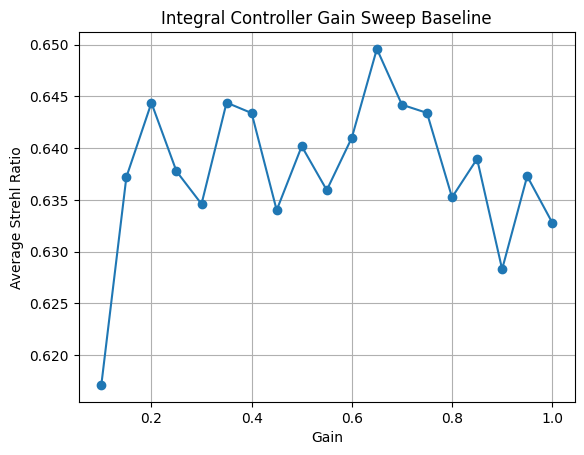

In [6]:
plt.figure()
plt.plot(env.gain_values, average_SR_list, marker='o')
plt.xlabel('Gain')
plt.ylabel('Average Strehl Ratio')
plt.title('Integral Controller Gain Sweep Baseline')
plt.grid()
plt.show()


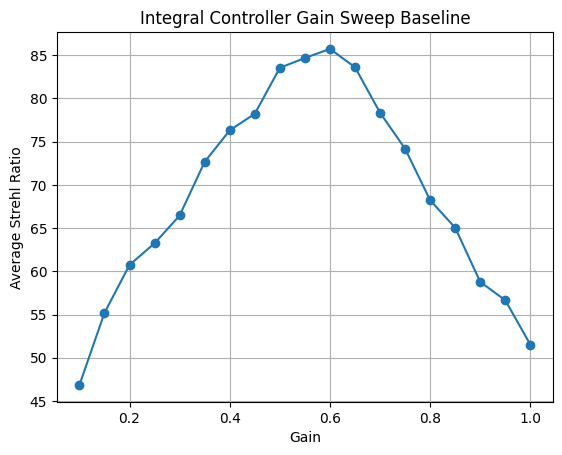

In [7]:
plt.figure()
plt.plot(env.gain_values, return_list, marker='o')
plt.xlabel('Gain')
plt.ylabel('Average Strehl Ratio')
plt.title('Integral Controller Gain Sweep Baseline')
plt.grid()
plt.show()

In [8]:
args2 = SimpleNamespace(
    agent = "PPO",
    episodes = 10,
    seed = 0,
    maxStep = 200,
    gainCL = 0.6,
    samplingRate = 1000,
    exposureTime = 1,
    clockRate = 1000,
    lightRatio = 0.3,
    paramFile = "paramFile1",  
    k = 3,
    delay=0
)
env2 = AOEnv(args2)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       5.0    29891304.3
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates load

 25%|██▌       | 1/4 [00:03<00:09,  3.27s/it]

100/357
Time elapsed: 3.2724649906158447 s


 50%|█████     | 2/4 [00:06<00:06,  3.10s/it]

200/357
Time elapsed: 2.975788116455078 s


 50%|█████     | 2/4 [00:08<00:08,  4.46s/it]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 记录所有 gain 下的平均 SR
average_SR_list2 = []
return_list2 = []
# 扫描所有 gain index
for gain_index in range(env2.gain_dim):
    obs = env2.reset()
    episode_return = 0
    done = False

    # 构造动作
    action = [gain_index, 4,8,9]  # gain index, sampling_rate=1000Hz, exposure=1.0, clock_rate=1000Hz

    while not done:
        state, reward, done, info = env2.step(action)
        episode_return += reward

    # 计算当前 gain 下平均 SR
    avg_SR = np.mean(env2.SR)
    average_SR_list2.append(avg_SR)
    return_list2.append(episode_return)

    # 如果需要，打印每次结果
    print(f"Gain index {gain_index}, gain value {env2.gain_values[gain_index]:.2f}, Average SR: {avg_SR:.4f}")





-> Computing the initial phase screen...
initial phase screen : 0.006682395935058594 s
ZZt.. : 1.3549654483795166 s
ZXt.. : 0.17731428146362305 s
XXt.. : 0.09280943870544434 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.006648063659667969 s
ZZt.. : 2.384185791015625e-07 s
ZXt.. : 1.7642974853515625e-05 s
XXt.. : 6.4373016357421875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.0059511661529541016 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 1.5020370483398438e-05 s
XXt.. : 6.4373016357421875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
Gain index 0, gain value 0.10, Average SR: 0.6515
Gain index 1, gain value 0.15, Average SR: 0.6855
Gain index 2, gain value 0.20, Average SR: 0.7014
Gain index 3, gain value 0.25, Average SR: 0.7079
Gain index 4, gain value 0.30, Average SR: 0.7110
Gain index 5, gain value 0.35, Average SR: 0.7153
Ga

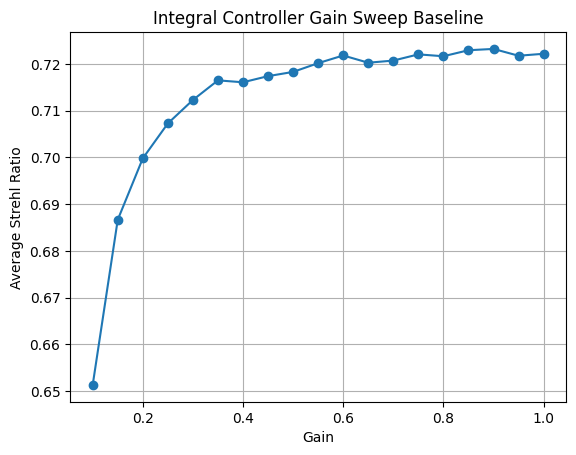

In [ ]:
plt.figure()
plt.plot(env2.gain_values, average_SR_list2, marker='o')
plt.xlabel('Gain')
plt.ylabel('Average Strehl Ratio')
plt.title('Integral Controller Gain Sweep Baseline')
plt.grid()
plt.show()

In [ ]:
import json
import matplotlib.pyplot as plt

# 读取文件
file_path = "/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir/AO1_R2DISC_lightRatio0.6_delay0_no_noise/metrics.jsonl"  # 换成你的文件路径
def draw(path, average_return):
    steps = []
    train_returns = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                record = json.loads(line.strip())
            except json.JSONDecodeError:
                continue
            if "train_return" in record:
                steps.append(record["step"])
                train_returns.append(record["train_return"])

    # 假设这是传统积分器的平均 return
    baseline_return = average_return   # <== 换成你实际的平均值

    # 画曲线
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_returns, color="tab:blue", linewidth=2, label="train_return")

    # 画虚线 (baseline)
    plt.axhline(y=baseline_return, color="tab:orange", linestyle="--", linewidth=2, label="Integrator Avg Return")

    plt.xlabel("Step")
    plt.ylabel("Train Return")
    # plt.title("Training Return Curve with Baseline")
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.show()

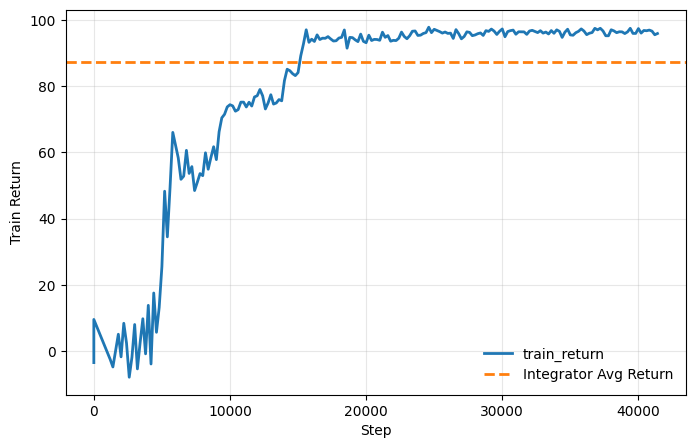

In [ ]:
draw(file_path,max(return_list))

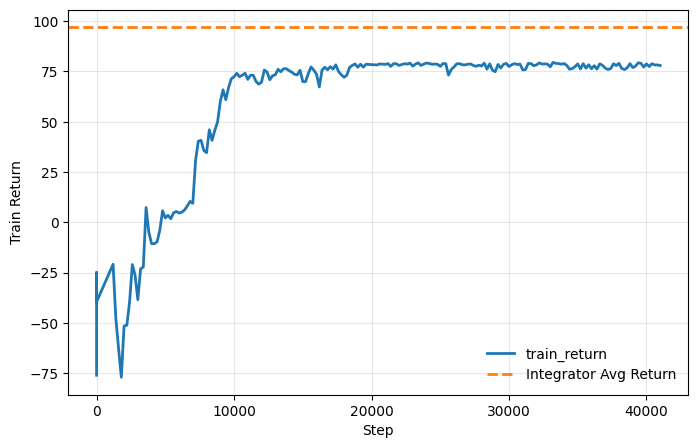

In [ ]:
file_path2 = '/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir/AO1_R2DISC_lightRatio0.6_delay2_with_noise/metrics.jsonl'
draw(file_path2,max(return_list2))

# 添加baseline

In [12]:
import os
import shutil
from torch.utils.tensorboard import SummaryWriter

def add_tensorboard_baseline(
    log_dir_root: str, 
    baseline_tag: str, 
    baseline_value: float, 
    max_steps: int, 
    log_frequency: int = 100
):
    """
    将固定的 Baseline 值作为一条水平曲线添加到 TensorBoard 日志中。

    Args:
        log_dir_root: 您的所有 TensorBoard 日志文件的根目录（例如 'runs'）。
        baseline_tag: Baseline 曲线的名称，应与您的训练指标名称具有相同的父级分组
                      （例如，训练指标是 'Loss/Validation'，这里可以是 'Loss/Baseline'）。
        baseline_value: 传统方法 Baseline 的固定数值。
        max_steps: 训练数据中最大的 global_step 值，用于确定 Baseline 曲线的长度。
        log_frequency: 每隔多少步记录一次 Baseline 值，以覆盖 X 轴（默认 100）。
    """
    
    # 1. 确定 Baseline 日志的路径
    # 使用 'baseline' 作为子文件夹名称，以确保其作为一个独立的 Run 显示。
    baseline_log_dir = os.path.join(log_dir_root, 'baseline_reference')
    
    # 2. 清理旧的 Baseline 文件 (可选，但推荐)
    if os.path.exists(baseline_log_dir):
        print(f"检测到旧的 Baseline 文件夹，正在删除：{baseline_log_dir}")
        shutil.rmtree(baseline_log_dir)

    # 3. 创建 SummaryWriter
    print(f"正在为 Baseline 写入日志到：{baseline_log_dir}")
    writer = SummaryWriter(baseline_log_dir)

    # 4. 循环写入 Baseline 值
    # 确保循环的步数从 0 覆盖到 max_steps
    for step in range(0, max_steps + log_frequency, log_frequency):
        # 核心：使用 add_scalar 记录，值保持不变，step 持续增加
        writer.add_scalar(baseline_tag, baseline_value, step)

    writer.close()
    print("Baseline 日志写入完成。")

# ----------------------------------------------------------------------
# 示例使用
# ----------------------------------------------------------------------

# 假设您的文件结构如下：
# 根目录/
# ├── my_training_log_1/
# └── my_training_log_2/

# 假设您的训练数据中：
# 1. 记录的指标名称是 'Reward/Final'
# 2. 最大的训练步数 (global_step) 是 9800

# 调用函数
try:
    add_tensorboard_baseline(
        log_dir_root='/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir',             # 您的日志文件所在的根目录
        baseline_tag='scalars/train_return', # 曲线名称
        baseline_value=93.8268,             # 传统方法的奖励值
        max_steps=40800                 # 确保覆盖所有训练步数
    )
    print("\n---")
    print("下一步：运行 TensorBoard 命令：")
    print("tensorboard --logdir runs")
    print("然后在 SCALARS 页面查看 'Reward' 图表，它将包含一条恒定的横线。")
    
except Exception as e:
    print(f"\n执行 Baseline 写入时发生错误：{e}")

检测到旧的 Baseline 文件夹，正在删除：/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir/baseline_reference
正在为 Baseline 写入日志到：/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir/baseline_reference
Baseline 日志写入完成。

---
下一步：运行 TensorBoard 命令：
tensorboard --logdir runs
然后在 SCALARS 页面查看 'Reward' 图表，它将包含一条恒定的横线。


Gain index 0, gain value 0.10, Average SR: 0.6528
Gain index 1, gain value 0.15, Average SR: 0.6888
Gain index 2, gain value 0.20, Average SR: 0.7029
Gain index 3, gain value 0.25, Average SR: 0.7084
Gain index 4, gain value 0.30, Average SR: 0.7071
Gain index 5, gain value 0.35, Average SR: 0.7040
Gain index 6, gain value 0.40, Average SR: 0.6964
Gain index 7, gain value 0.45, Average SR: 0.6870


KeyboardInterrupt: 

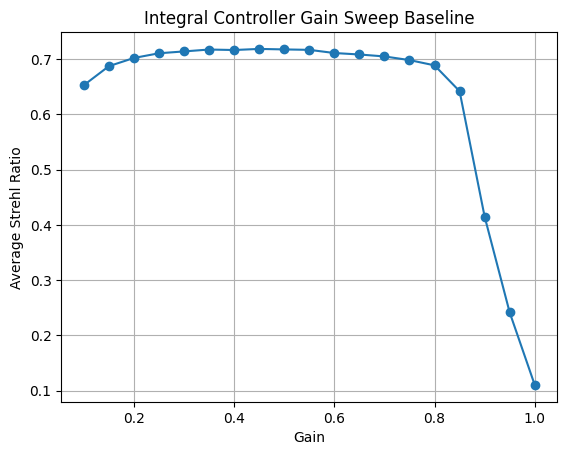

In [ ]:
# 绘制 gain vs average SR 曲线


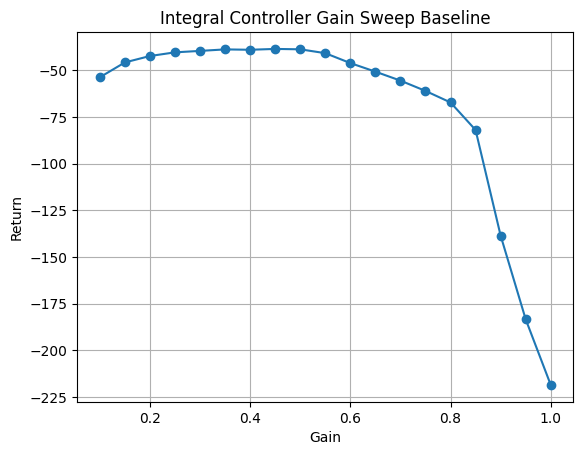

In [ ]:
plt.figure()
plt.plot(env.gain_values, return_list, marker='o')
plt.xlabel('Gain')
plt.ylabel('Return')
plt.title('Integral Controller Gain Sweep Baseline')
plt.grid()
plt.show()